1) Loading the dataset

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

 2. Exploring the dataset

In [25]:
data = load_diabetes()

x = data.data
y = data.target

print('Feature name : ',data.feature_names)
print('First five target values :', y[:5])

Feature name :  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
First five target values : [151.  75. 141. 206. 135.]


In [26]:
print(x.shape)
print(y.shape)


(442, 10)
(442,)


3. Preparing the Data

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Standardization puts numerical features on a common scale, usually with mean 0 and standard deviation 1, so ML algorithms can learn more effectively.

In [28]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

x = feature_scaler.fit_transform(x)

y = y.reshape(-1,1)
y = target_scaler.fit_transform(y)
y = y.ravel()

x , x_test , y , y_test = train_test_split(x , y , test_size = 0.2 , random_state=42)
x_val , x_test , y_val , y_test = train_test_split(x_test , y_test , test_size=0.5, random_state=42)


In [29]:
print('train')
print(x.shape)
print(y.shape)

print('test')
print(x_test.shape)
print(y_test.shape)

print('val')
print(x_val.shape)
print(y_val.shape)

train
(353, 10)
(353,)
test
(45, 10)
(45,)
val
(44, 10)
(44,)


4. Initialising parameters

In [30]:
m , n = x.shape  # m = 353 , n = 10
w = np.zeros(n)  #Weight vector (shape : [10,])
b = 0            # Bias term (scalar)

   # So the model is basically saying that take every feature,
   # multiply it by its weight,
   # add everything together,
   # then add the bias

In [31]:
def predict(x , w , b):
  return np.dot(x,w) + b


5. Defining the cost function or (MSE)

In [32]:
def compute_cost( x , y , w , b ):
  m = len(y)

  y_pred = predict(x , w , b )

  cost = (1/(2*m)*np.sum( y_pred - y )**2)

  return cost

6. Computing the gradient

In [33]:
def compute_gradients( x , y , w , b ):
  m = len(y)

  y_pred = predict( x , w , b )
  error = y_pred - y
  dw = (1/m) * np.dot( x.T , error)
  db = (1/m) * np.sum(error)

  return dw,db



7. Updating Parameter Using Gradient Descent

In [34]:
def update_parameters( w , b , dw , db , learning_rate) :
  w = w - learning_rate * dw
  b = b - learning_rate * db

  return w , b

  # Here negative sign tells us that
  # we are going in the opposite direction for minimising the error.
  # Hence the name Gradient Descent comes into the picture

8. Training the data

In [35]:
w = np.zeros(n)
b = 0

learning_rate = .001 # How big each step must be while moving from one
                     # weight to another

9. Training the model

In [36]:
w = np.zeros(n)
b = 0

learning_rate = .001
num_iterations = 2500
cost_history  = []

parameters = {}

for i in range (num_iterations):
  y_pred = predict(x , w , b)
  cost = compute_cost( x , y , w , b )
  dw , db = compute_gradients( x , y , w , b )
  w , b = update_parameters( w , b , dw , db , learning_rate)

  val_cost = compute_cost( x_val , y_val , w , b )

  if i % 100 == 0 :
    cost_history.append([cost , val_cost])
    print(f'Iteration {i} : Cost = {cost:.4f}: Val Cost = {val_cost:.4f}')
    parameters = {'weights': w.tolist() , 'bias': b}


Iteration 0 : Cost = 0.0765: Val Cost = 0.3287
Iteration 100 : Cost = 0.0280: Val Cost = 0.2353
Iteration 200 : Cost = 0.0081: Val Cost = 0.1710
Iteration 300 : Cost = 0.0012: Val Cost = 0.1254
Iteration 400 : Cost = 0.0000: Val Cost = 0.0923
Iteration 500 : Cost = 0.0010: Val Cost = 0.0680
Iteration 600 : Cost = 0.0026: Val Cost = 0.0498
Iteration 700 : Cost = 0.0041: Val Cost = 0.0362
Iteration 800 : Cost = 0.0053: Val Cost = 0.0259
Iteration 900 : Cost = 0.0062: Val Cost = 0.0182
Iteration 1000 : Cost = 0.0066: Val Cost = 0.0124
Iteration 1100 : Cost = 0.0068: Val Cost = 0.0082
Iteration 1200 : Cost = 0.0067: Val Cost = 0.0051
Iteration 1300 : Cost = 0.0065: Val Cost = 0.0029
Iteration 1400 : Cost = 0.0062: Val Cost = 0.0015
Iteration 1500 : Cost = 0.0058: Val Cost = 0.0006
Iteration 1600 : Cost = 0.0053: Val Cost = 0.0001
Iteration 1700 : Cost = 0.0049: Val Cost = 0.0000
Iteration 1800 : Cost = 0.0044: Val Cost = 0.0001
Iteration 1900 : Cost = 0.0039: Val Cost = 0.0004
Iteration 20

The lesser the cost the better it is for the model
In the above case the cost is decreasing which is a good sign as we can say the error is decreasing

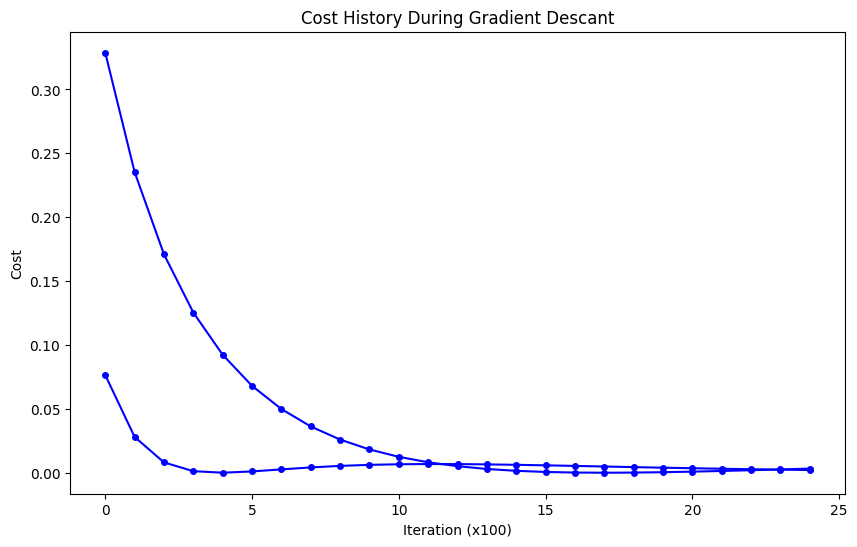

In [37]:
plt.figure(figsize=(10,6))

plt.plot(range(len(cost_history)) , cost_history , marker='o' , linestyle='-' , color='b' , markersize=4)
plt.title('Cost History During Gradient Descant')
plt.xlabel('Iteration (x100)')
plt.ylabel('Cost')

plt.show()

In [38]:
y_test_pred  = np.dot(x_test , w ) + b
print( sum(abs( y_test_pred - y_test )) / 45 )

0.5830664432915753


In [39]:
import json
param = {'weights': w.tolist(), 'bias': b}
with open('param.json', 'w') as f:
  json.dump(param, f)

 Mini Batch Gradient Descent

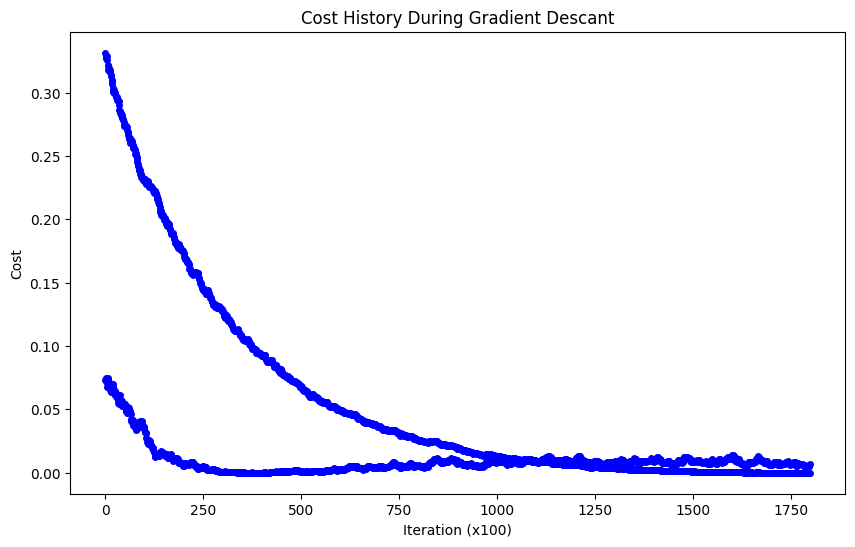

In [44]:
w = np.zeros(n)
b = 0

learning_rate = .001
epochs = 50  # The whole training data will be traversed 50 times
cost_history = []

parameters = {}

batch_size = 10 # Parameter will be updated 10 times

for i in range(epochs):
  # Shuffling the data at the beginning of each epoch for better generalisation
  permutation = np.random.permutation(x.shape[0])
  x_shuffled = x[permutation]
  y_shuffled = y[permutation]

  for j in range(0,x.shape[0],batch_size):
    x_batch = x_shuffled[j:j + batch_size]
    y_batch = y_shuffled[j:j + batch_size]

    dw,db = compute_gradients( x_batch , y_batch , w , b )
    w,b = update_parameters( w , b , dw , db , learning_rate)


    #Calculating Training and validation cost at the end of each epoch

    val_cost = compute_cost( x_val , y_val , w , b )
    train_cost_epoch_end = compute_cost( x , y , w , b )

    cost_history.append([ train_cost_epoch_end , val_cost ])
    # print(f'Epoch {i} : Train Cost = {train_cost_epoch_end:.4f}: Val Cost = {val_cost:.4f}')
    parameters = {'weights': w.tolist(), 'bias':b}


plt.figure(figsize=(10,6))

plt.plot(range(len(cost_history)) , cost_history , marker='o' , linestyle='-' , color='b' , markersize=4)
plt.title('Cost History During Gradient Descant')
plt.xlabel('Iteration (x100)')
plt.ylabel('Cost')

plt.show()

 Stochastic Gradient Descent

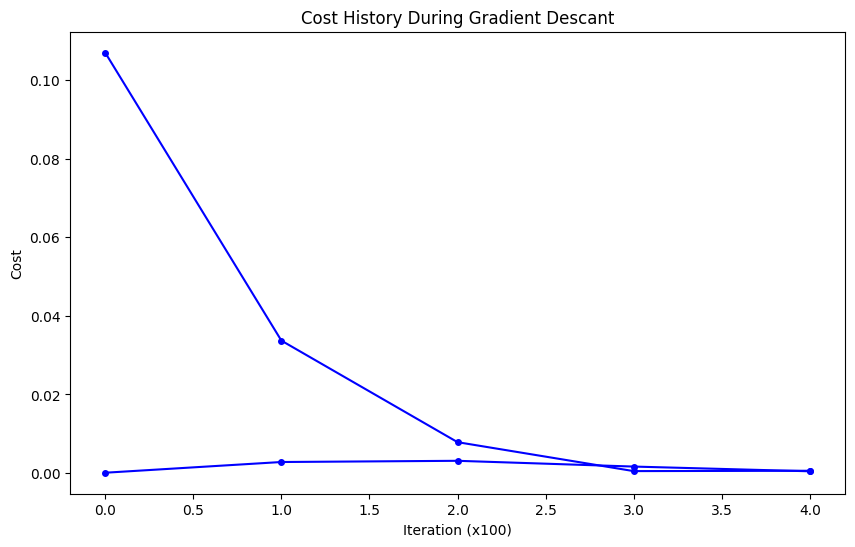

In [43]:
w = np.zeros(n)
b = 0

learning_rate = .001
epochs = 5  # The whole training data will be traversed 5 times
cost_history = []

parameters = {}

# ---------------------------------------------------------------

def compute_cost_single(x_single, y_single, w, b):
    y_pred_single = predict(x_single, w, b)
    cost_single = (1 / 2) * (y_pred_single - y_single) ** 2
    return cost_single

# ---------------------------------------------------------------

def compute_gradients_single(x_single, y_single, w, b):

    y_pred_single = predict(x_single, w, b)

    error_single = y_pred_single - y_single

    dw_single = error_single * x_single
    db_single = error_single

    return dw_single, db_single

# ----------------------------------------------------------------

for i in range(epochs):

    for x_curr, y_curr in zip(x, y):
      # zip(x, y) pairs the training data with target data
      # so that the inner loop process one example at a time
      cost_curr = compute_cost_single(x_curr, y_curr, w, b)
      #to calculate the cost for one example/row

      dw_curr, db_curr = compute_gradients_single(x_curr, y_curr, w, b)
      # to calculate gradients using one example/row

      w, b = update_parameters(w, b, dw_curr, db_curr, learning_rate)
      # to update w and b


      val_cost = compute_cost( x_val , y_val , w , b )
      train_cost_epoch_end = compute_cost( x , y , w , b )
      # print( val_cost , train_cost_epoch_end )


    #to calculate validation cost using the original batch compute_cost
    val_cost = compute_cost( x_val , y_val , w , b )
    train_cost_epoch_end = compute_cost( x , y , w , b )

    cost_history.append( [train_cost_epoch_end , val_cost] )

    parameters = {'weights': w.tolist(), 'bias': b}



plt.figure(figsize=(10,6))
plt.plot(range(len(cost_history)) , cost_history , marker='o' , linestyle='-' , color='b' , markersize=4)
plt.title('Cost History During Gradient Descant')
plt.xlabel('Iteration (x100)')
plt.ylabel('Cost')

plt.show()
